In [1]:
import pandas as pd

orders = pd.read_csv("data/raw/olist_orders_dataset.csv")

print("Orders shape:", orders.shape)

orders.head()


Orders shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


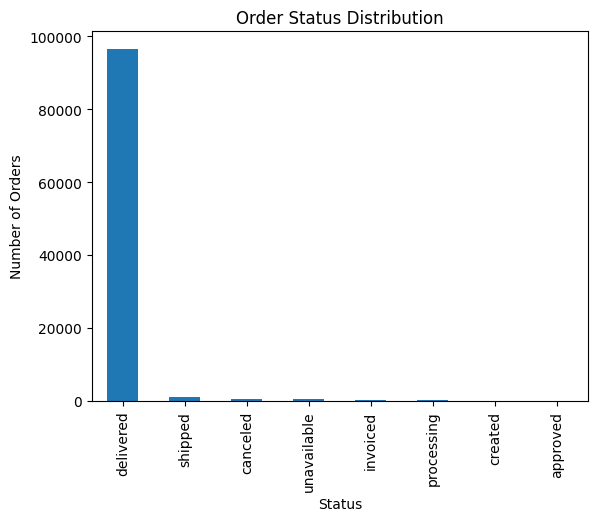

In [3]:
import matplotlib.pyplot as plt

orders["order_status"].value_counts().plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Orders")

plt.show()


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
customers = pd.read_csv("data/raw/olist_customers_dataset.csv")

print(customers.shape)

customers.head()

(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
customers["customer_state"].value_counts().head(10)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [8]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [9]:
import pandas as pd
import os

# Load all CSV files into a dict of DataFrames
data_path = "data/raw/"
tables = {}
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        name = file.replace("olist_", "").replace("_dataset.csv", "")
        tables[name] = pd.read_csv(os.path.join(data_path, file))
        print(f"Loaded {name}: {tables[name].shape}")

# Inspect orders table
orders = tables['orders']
print(orders.head())
print(orders.dtypes)
print(orders.isnull().sum())

Loaded customers: (99441, 5)
Loaded geolocation: (1000163, 5)
Loaded orders: (99441, 8)
Loaded order_items: (112650, 7)
Loaded order_payments: (103886, 5)
Loaded order_reviews: (99224, 7)
Loaded products: (32951, 9)
Loaded sellers: (3095, 4)
Loaded product_category_name_translation.csv: (71, 2)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    deli

In [ ]:
!pip install google-cloud-bigquery pandas pyarrow db-dtypes


In [13]:
from google.cloud import bigquery
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "credentials/gcp-key.json"

client = bigquery.Client(project="bizanalytics-project")

query = """
SELECT CURRENT_DATE() AS today
"""

result = client.query(query).to_dataframe()

print(result)

DefaultCredentialsError: File credentials/gcp-key.json was not found.

In [14]:
import os

print(os.getcwd())
print(os.path.exists("credentials/gcp-key.json"))


C:\Users\asus\bizanalytics-platform
False


In [15]:
import os
print(os.getcwd())

C:\Users\asus\bizanalytics-platform


In [16]:
import os

print(os.listdir("credentials"))

['gcp-key.json.json']


In [17]:
from google.cloud import bigquery
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "credentials/gcp-key.json"

client = bigquery.Client(project="bizanalytics-project")

query = """
SELECT CURRENT_DATE() AS today
"""

result = client.query(query).to_dataframe()

print(result)

C:\Users\asus\New folder\envs\bizanalytics\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


        today
0  2026-06-09


In [18]:
from google.cloud import bigquery

client = bigquery.Client(project="bizanalytics-project")

print(client.project)

bizanalytics-project


In [19]:
import os

print(os.listdir("data"))

['raw']


In [20]:
import os

for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

data\raw\olist_customers_dataset.csv
data\raw\olist_geolocation_dataset.csv
data\raw\olist_orders_dataset.csv
data\raw\olist_order_items_dataset.csv
data\raw\olist_order_payments_dataset.csv
data\raw\olist_order_reviews_dataset.csv
data\raw\olist_products_dataset.csv
data\raw\olist_sellers_dataset.csv
data\raw\product_category_name_translation.csv


In [21]:
import os

print(os.listdir("data/raw"))

['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [22]:
with open(".gitignore", "w") as f:
    f.write("""# NEVER commit these to GitHub
credentials/
.env
*.json
__pycache__/
.DS_Store
*.pyc
.ipynb_checkpoints/
""")

In [23]:
import os

print(os.listdir("data/raw"))


['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [24]:
from google.cloud import bigquery
import pandas as pd
import os

# Connect to BigQuery
client = bigquery.Client(project="bizanalytics-project")

# Dataset name
dataset_id = "ecommerce_raw"

# Folder containing CSV files
folder = "data/raw"

# Upload every CSV file
for file in os.listdir(folder):

    if file.endswith(".csv"):

        # Create table name
        table_name = file.replace("olist_", "") \
                         .replace("_dataset.csv", "") \
                         .replace(".csv", "")

        table_id = f"bizanalytics-project.{dataset_id}.{table_name}"

        print(f"Uploading {file} → {table_name}")

        df = pd.read_csv(os.path.join(folder, file))

        job = client.load_table_from_dataframe(
            df,
            table_id,
            job_config=bigquery.LoadJobConfig(
                write_disposition="WRITE_TRUNCATE"
            )
        )

        job.result()

        print(f"✓ Uploaded {table_name}")

Uploading olist_customers_dataset.csv → customers
✓ Uploaded customers
Uploading olist_geolocation_dataset.csv → geolocation
✓ Uploaded geolocation
Uploading olist_orders_dataset.csv → orders
✓ Uploaded orders
Uploading olist_order_items_dataset.csv → order_items
✓ Uploaded order_items
Uploading olist_order_payments_dataset.csv → order_payments
✓ Uploaded order_payments
Uploading olist_order_reviews_dataset.csv → order_reviews
✓ Uploaded order_reviews
Uploading olist_products_dataset.csv → products
✓ Uploaded products
Uploading olist_sellers_dataset.csv → sellers
✓ Uploaded sellers
Uploading product_category_name_translation.csv → product_category_name_translation
✓ Uploaded product_category_name_translation


In [25]:
import pandas as pd
import os

In [26]:
customers = pd.read_csv("data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("data/raw/olist_orders_dataset.csv")
payments = pd.read_csv("data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("data/raw/olist_products_dataset.csv")

In [27]:
print(customers.shape)
print(orders.shape)
print(payments.shape)
print(reviews.shape)
print(products.shape)

(99441, 5)
(99441, 8)
(103886, 5)
(99224, 7)
(32951, 9)


In [28]:
print("\nCustomers:")
print(customers.isnull().sum())

print("\nOrders:")
print(orders.isnull().sum())

print("\nPayments:")
print(payments.isnull().sum())

print("\nReviews:")
print(reviews.isnull().sum())

print("\nProducts:")
print(products.isnull().sum())


Customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Payments:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Reviews:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Products:
product_id                      0
product_category_name         610
product_name

In [29]:
customers = customers.drop_duplicates()
orders = orders.drop_duplicates()
payments = payments.drop_duplicates()
reviews = reviews.drop_duplicates()
products = products.drop_duplicates()

In [30]:
print(customers.shape)
print(orders.shape)
print(payments.shape)
print(reviews.shape)
print(products.shape)

(99441, 5)
(99441, 8)
(103886, 5)
(99224, 7)
(32951, 9)


In [31]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_approved_at'] = pd.to_datetime(
    orders['order_approved_at']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [32]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](4), object(4)
memory usage: 6.1+ MB


In [33]:
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_day'] = orders['order_purchase_timestamp'].dt.day

In [34]:
orders[['order_purchase_timestamp',
        'order_year',
        'order_month',
        'order_day']].head()

,order_purchase_timestamp,order_year,order_month,order_day
0,2017-10-02 10:56:33,2017,10,2
1,2018-07-24 20:41:37,2018,7,24
2,2018-08-08 08:38:49,2018,8,8
3,2017-11-18 19:28:06,2017,11,18
4,2018-02-13 21:18:39,2018,2,13


In [35]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

In [36]:
orders[['order_purchase_timestamp',
         'order_delivered_customer_date',
         'delivery_days']].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


In [37]:
avg_review = reviews.groupby('order_id')['review_score'].mean().reset_index()
avg_review.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [38]:
total_payment = payments.groupby('order_id')['payment_value'].sum().reset_index()
total_payment.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [39]:
orders = orders.merge(avg_review, on='order_id', how='left')

orders = orders.merge(total_payment, on='order_id', how='left')

In [40]:
os.makedirs("data/processed", exist_ok=True)

In [41]:
orders.to_csv(
    "data/processed/orders_cleaned.csv",
    index=False
)

In [42]:
print(os.listdir("data/processed"))

['orders_cleaned.csv']
